In [1]:
# Cell 1 - Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
NumPy version: 2.3.4
Pandas version: 2.3.3


In [2]:
# Cell 2 - SensorSimulator Class
# This class mimics what your Arduino was doing — generating sensor readings
# Instead of reading from real hardware, it generates realistic numbers

import numpy as np

class SensorSimulator:
    """
    Simulates IoT sensor readings for banana farm monitoring.
    Each scenario mimics a real condition from the AgroAssist patent experiment.
    """
    
    # These ranges come directly from your patent's experimental data
    SCENARIOS = {
        'healthy': {
            'soil_moisture': (50, 70),   # % volumetric water content
            'soil_ph':       (5.5, 6.5), # ideal banana pH range
            'soil_ec':       (1.2, 2.0), # mS/cm - good nutrient level
            'rgb_red':       (60, 80),   # leaf red channel
            'rgb_green':     (90, 120),  # leaf green channel - high = healthy
            'rgb_blue':      (40, 60),   # leaf blue channel
            'temperature':   (22, 30),   # °C - optimal banana growth
            'humidity':      (60, 75),   # % - normal range
            'leaf_wetness':  (0, 30),    # 0-100 scale - dry to wet
        },
        'nitrogen_deficient': {
            'soil_moisture': (45, 65),
            'soil_ph':       (5.0, 6.0),
            'soil_ec':       (0.4, 0.8), # EC drops when N is low
            'rgb_red':       (90, 120),  # leaves yellow → red channel rises
            'rgb_green':     (50, 75),   # green channel DROPS - key indicator
            'rgb_blue':      (30, 50),
            'temperature':   (22, 32),
            'humidity':      (55, 75),
            'leaf_wetness':  (0, 25),
        },
        'sigatoka_risk': {
            'soil_moisture': (55, 75),
            'soil_ph':       (5.5, 6.5),
            'soil_ec':       (1.0, 1.8),
            'rgb_red':       (70, 95),
            'rgb_green':     (70, 100),
            'rgb_blue':      (45, 65),
            'temperature':   (25, 32),   # warm temp
            'humidity':      (85, 98),   # HIGH humidity = fungal risk
            'leaf_wetness':  (60, 95),   # HIGH wetness = Sigatoka trigger
        },
        'water_stress': {
            'soil_moisture': (15, 35),   # moisture DROPS
            'soil_ph':       (6.0, 7.0), # pH rises under drought
            'soil_ec':       (2.5, 4.0), # EC SPIKES when moisture drops
            'rgb_red':       (85, 110),
            'rgb_green':     (60, 85),   # slight green drop
            'rgb_blue':      (35, 55),
            'temperature':   (28, 38),   # hotter = more stress
            'humidity':      (35, 55),   # low humidity
            'leaf_wetness':  (0, 15),    # very dry
        }
    }
    
    def __init__(self, scenario='healthy'):
        self.scenario = scenario
        self.ranges = self.SCENARIOS[scenario]
    
    def get_reading(self):
        """Generate one sensor reading with realistic random noise"""
        reading = {}
        for sensor, (low, high) in self.ranges.items():
            # np.random.uniform picks a random number between low and high
            base_value = np.random.uniform(low, high)
            # Add tiny noise (±2%) to simulate real sensor fluctuation
            noise = base_value * np.random.uniform(-0.02, 0.02)
            reading[sensor] = round(base_value + noise, 2)
        reading['scenario'] = self.scenario
        return reading


# Quick test - generate one reading from each scenario
for scenario in SensorSimulator.SCENARIOS.keys():
    sim = SensorSimulator(scenario)
    reading = sim.get_reading()
    print(f"\nScenario: {scenario.upper()}")
    print(f"  EC: {reading['soil_ec']} | Green: {reading['rgb_green']} | Humidity: {reading['humidity']} | Wetness: {reading['leaf_wetness']}")


Scenario: HEALTHY
  EC: 1.43 | Green: 110.99 | Humidity: 64.5 | Wetness: 27.34

Scenario: NITROGEN_DEFICIENT
  EC: 0.6 | Green: 55.26 | Humidity: 64.72 | Wetness: 17.9

Scenario: SIGATOKA_RISK
  EC: 1.68 | Green: 87.52 | Humidity: 96.34 | Wetness: 94.25

Scenario: WATER_STRESS
  EC: 2.92 | Green: 81.87 | Humidity: 51.32 | Wetness: 12.23


In [4]:
# Cell 3 - Generate Full Dataset
# We run the simulator 1000 times across all 4 scenarios
# and save every reading as a row in a CSV file

def generate_dataset(readings_per_scenario=250):
    """
    250 readings × 4 scenarios = 1000 total rows
    This becomes our training dataset for the ML models
    """
    all_readings = []
    
    for scenario in SensorSimulator.SCENARIOS.keys():
        sim = SensorSimulator(scenario)
        for i in range(readings_per_scenario):
            reading = sim.get_reading()
            all_readings.append(reading)
    
    # Convert list of dictionaries → Pandas DataFrame (a table)
    df = pd.DataFrame(all_readings)
    
    # Shuffle the rows so scenarios aren't all grouped together
    # frac=1 means shuffle 100% of rows, random_state=42 means reproducible
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df

# Generate the dataset
df = generate_dataset(readings_per_scenario=250)

# Save to CSV inside our data/ folder
df.to_csv('../data/sensor_data.csv', index=False)

# Preview what we created
print(f"Dataset shape: {df.shape}")  # (rows, columns)
print(f"Scenarios: {df['scenario'].value_counts().to_dict()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 10)
Scenarios: {'sigatoka_risk': 250, 'nitrogen_deficient': 250, 'water_stress': 250, 'healthy': 250}

First 5 rows:


,soil_moisture,soil_ph,soil_ec,rgb_red,rgb_green,rgb_blue,temperature,humidity,leaf_wetness,scenario
0,72.00,6.45,1.00,81.52,71.75,56.82,27.83,91.51,82.71,sigatoka_risk
1,73.62,6.43,1.73,86.36,90.35,51.34,28.01,90.92,83.11,sigatoka_risk
2,59.01,5.77,1.34,77.90,75.85,56.58,25.99,91.48,79.99,sigatoka_risk
3,58.59,6.18,1.05,69.96,85.21,45.37,26.78,89.02,83.89,sigatoka_risk
4,60.39,5.70,0.54,110.01,52.38,37.54,27.38,68.12,17.52,nitrogen_deficient


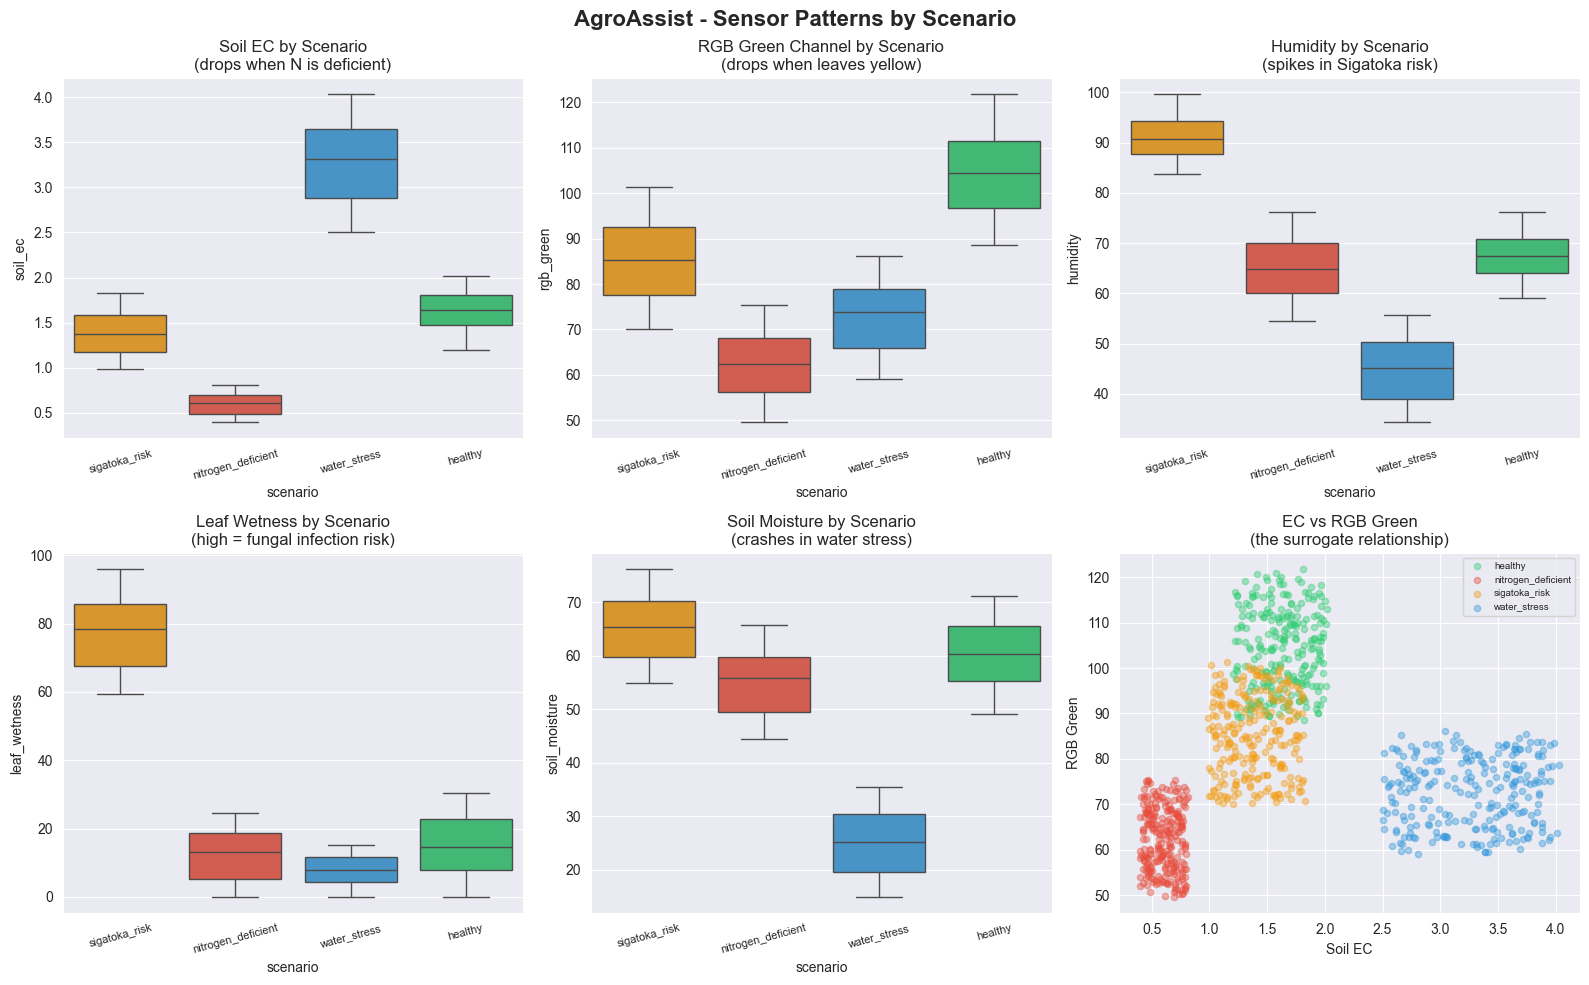

EDA plots saved to data/eda_plots.png


In [5]:
# Cell 4 - Exploratory Data Analysis (EDA)
# EDA means "let's look at the data visually before training any model"
# We want to SEE the patterns the ML model will later learn

# Load the saved CSV
df = pd.read_csv('../data/sensor_data.csv')

# Set a clean visual style
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('AgroAssist - Sensor Patterns by Scenario', fontsize=16, fontweight='bold')

# Color map for each scenario
colors = {
    'healthy': '#2ecc71',
    'nitrogen_deficient': '#e74c3c', 
    'sigatoka_risk': '#f39c12',
    'water_stress': '#3498db'
}

# Plot 1 - EC by scenario (key surrogate indicator)
sns.boxplot(data=df, x='scenario', y='soil_ec', 
            ax=axes[0,0], palette=colors)
axes[0,0].set_title('Soil EC by Scenario\n(drops when N is deficient)')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=15, fontsize=8)

# Plot 2 - RGB Green by scenario (leaf colour indicator)
sns.boxplot(data=df, x='scenario', y='rgb_green',
            ax=axes[0,1], palette=colors)
axes[0,1].set_title('RGB Green Channel by Scenario\n(drops when leaves yellow)')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=15, fontsize=8)

# Plot 3 - Humidity by scenario (disease risk indicator)
sns.boxplot(data=df, x='scenario', y='humidity',
            ax=axes[0,2], palette=colors)
axes[0,2].set_title('Humidity by Scenario\n(spikes in Sigatoka risk)')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=15, fontsize=8)

# Plot 4 - Leaf wetness by scenario
sns.boxplot(data=df, x='scenario', y='leaf_wetness',
            ax=axes[1,0], palette=colors)
axes[1,0].set_title('Leaf Wetness by Scenario\n(high = fungal infection risk)')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=15, fontsize=8)

# Plot 5 - Soil moisture by scenario
sns.boxplot(data=df, x='scenario', y='soil_moisture',
            ax=axes[1,1], palette=colors)
axes[1,1].set_title('Soil Moisture by Scenario\n(crashes in water stress)')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=15, fontsize=8)

# Plot 6 - EC vs RGB Green scatter (the core surrogate relationship)
for scenario, color in colors.items():
    subset = df[df['scenario'] == scenario]
    axes[1,2].scatter(subset['soil_ec'], subset['rgb_green'], 
                      c=color, label=scenario, alpha=0.4, s=20)
axes[1,2].set_xlabel('Soil EC')
axes[1,2].set_ylabel('RGB Green')
axes[1,2].set_title('EC vs RGB Green\n(the surrogate relationship)')
axes[1,2].legend(fontsize=7)

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved to data/eda_plots.png")